Let V(x) = A * cos(πx/a) + A/2 * cos(2πx/a) + A/3 * cos(3πx/a) with A=3eV.
1. Plot the band structure in the first and second BZ for at least 5 bands.
2. Plot the corresponding density of states.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

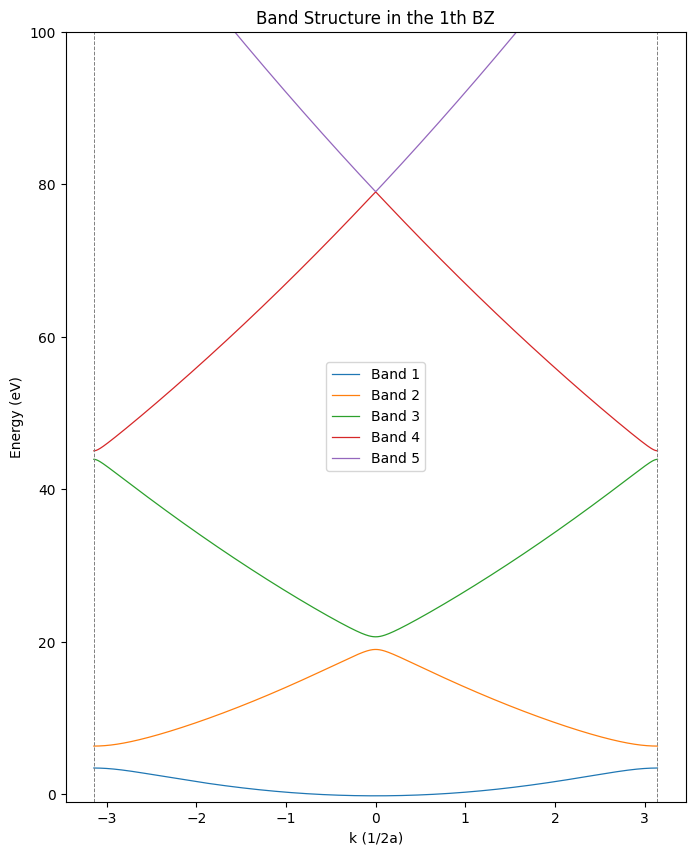

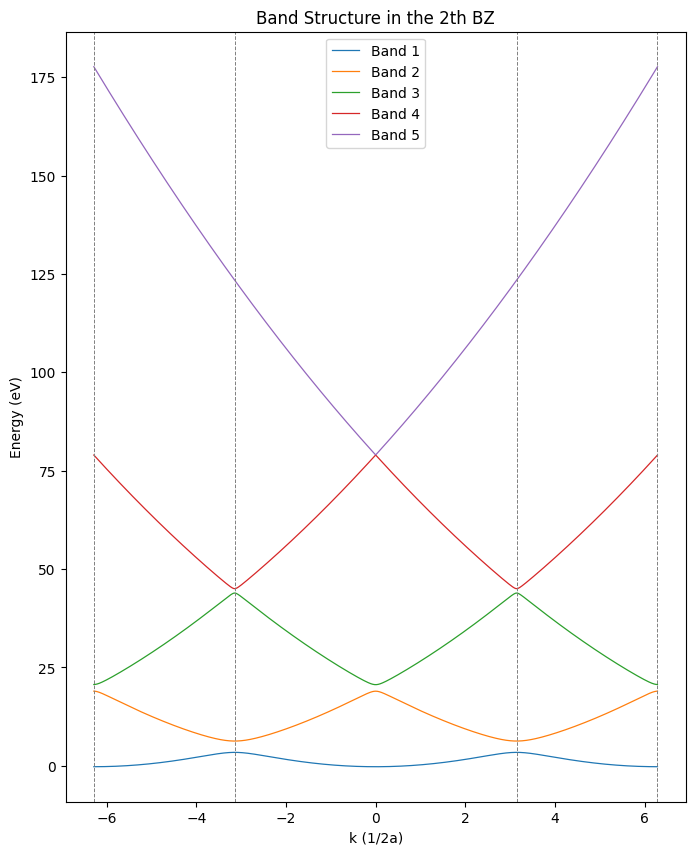

In [ ]:
# Question 1: Plot the band structure in the first and second BZ for at least 5 bands.
#Here lattice constant is 2a
def band_structure(A,a,levels,bz,V_G_values,N):
    k_values = np.linspace((-2*bz*np.pi)/(2*a),(2*bz*np.pi)/(2*a), N) # k points in the bz Brillouin zone
    bands = np.zeros((levels, len(k_values)))
    for i_, k in enumerate(k_values):
        H = np.zeros((levels, levels), dtype=float)
        G = 2 * np.pi / a
        g_values = np.array([ n * G for n in range(-levels//2 + 1, levels//2 + 1)])
        for i in range(levels):
            for j in range(levels):
                if i == j:
                    H[i, j] =  0.5*((k - g_values[i])**2) # in atomic units
                else:
                    H[i, j] = V_G_values.get(abs(i-j), 0)
        eigenvalues, _ = np.linalg.eigh(H)
        bands[:, i_] = eigenvalues 
    return k_values, bands

def plot_bands(A,a,levels,bz, V_G_values,N):
    k_values,bands = band_structure(A,a,levels,bz, V_G_values,N)
    plt.figure(figsize=(8, 10))
    for i in range(bands.shape[0]):
        plt.plot(k_values, bands[i], label=f'Band {i+1}',linewidth=0.9)
    if bz == 1:
        plt.axvline(-np.pi/a, color='grey', linestyle='--', linewidth=0.7)
        plt.axvline(np.pi/a, color='grey', linestyle='--', linewidth=0.7)
    elif bz == 2:
        plt.axvline(-2*np.pi/a, color='grey', linestyle='--', linewidth=0.7)
        plt.axvline(-np.pi/a, color='grey', linestyle='--', linewidth=0.7)
        plt.axvline(np.pi/a, color='grey', linestyle='--', linewidth=0.7)
        plt.axvline(2*np.pi/a, color='grey', linestyle='--', linewidth=0.7)
    plt.title(f'Band Structure in the {bz}th BZ')
    plt.xlabel('k (1/2a)')
    plt.ylabel('Energy (eV)')
    plt.grid(False)
    plt.legend()

A = 3  # eV Amplitude of the potential
a = 1  # Lattice constant
# Plotting band structure in the 1st BZ
VG_values = {1: A / 2, 2: A / 4, 3: A / 6}
plot_bands(A, a, levels=5, bz=1, V_G_values=VG_values,N = 2000)
plt.ylim(-1, 100)   
plt.show()
# Plotting band structure in the 2nd BZ
plot_bands(A, a, levels=5, bz=2, V_G_values=VG_values,N = 2000)
plt.show()

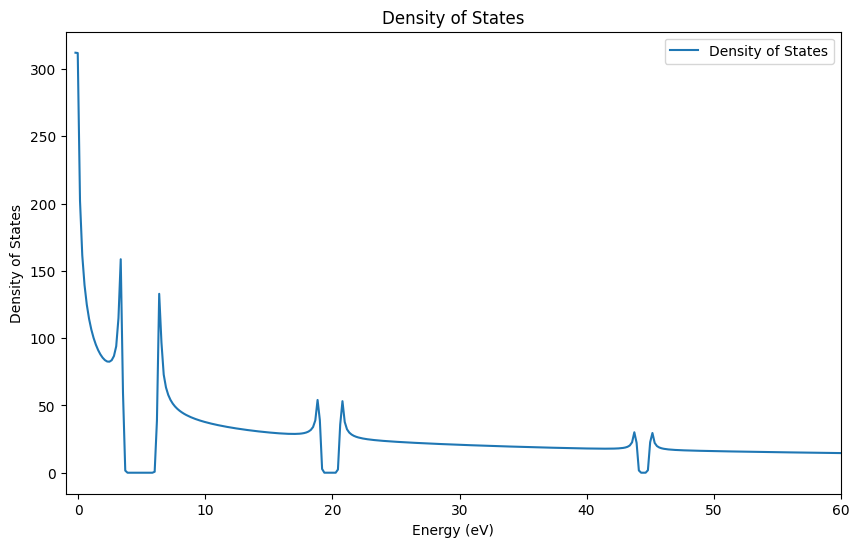

In [3]:
# Question 2: Plot the density of states for the same parameters as in question 1.

def density_of_states(A, a, levels, bz, V_G_values, N):
    k_values, bands = band_structure(A, a, levels, bz, V_G_values, N)
    energy_range = np.linspace(np.min(bands), np.max(bands), 1000)
    dos = np.zeros_like(energy_range)
    for i in range(bands.shape[0]):
        for j in range(bands.shape[1]):
            dos += np.exp(-(energy_range - bands[i, j])**2 / (2 * (0.1)**2))  # Gaussian broadening with sigma = 0.1 eV
    return energy_range, dos


def plot_dos(A, a, levels, bz, V_G_values, N):
    energy_range, dos = density_of_states(A, a, levels, bz, V_G_values, N)
    plt.figure(figsize=(10, 6))
    plt.plot(energy_range, dos, label='Density of States')
    plt.title(f'Density of States')
    plt.xlabel('Energy (eV)')
    plt.ylabel('Density of States')
    plt.grid(False)
    plt.legend()
    

# Plotting density of states in the 1st and 2nd BZ
plot_dos(A, a, levels=5, bz=2, V_G_values=VG_values,N = 2000)
plt.xlim(-1, 60)
plt.show()

Converge the band-structure w.r.t the increasing number of Fourier basis used for
expansion of the Bloch states. (In class we mostly wrote it for five plane wave
basis with G from G-2 to G2).

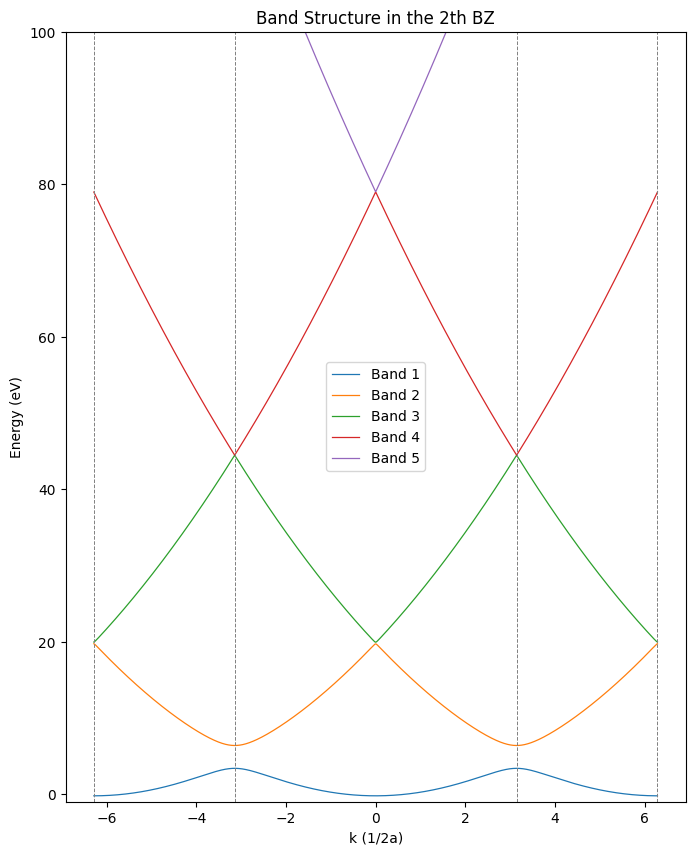

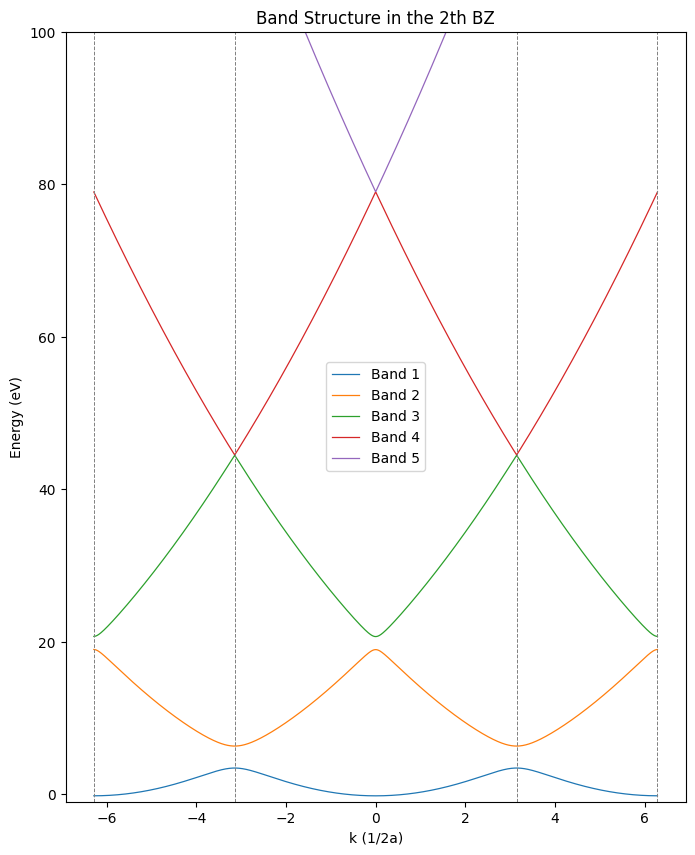

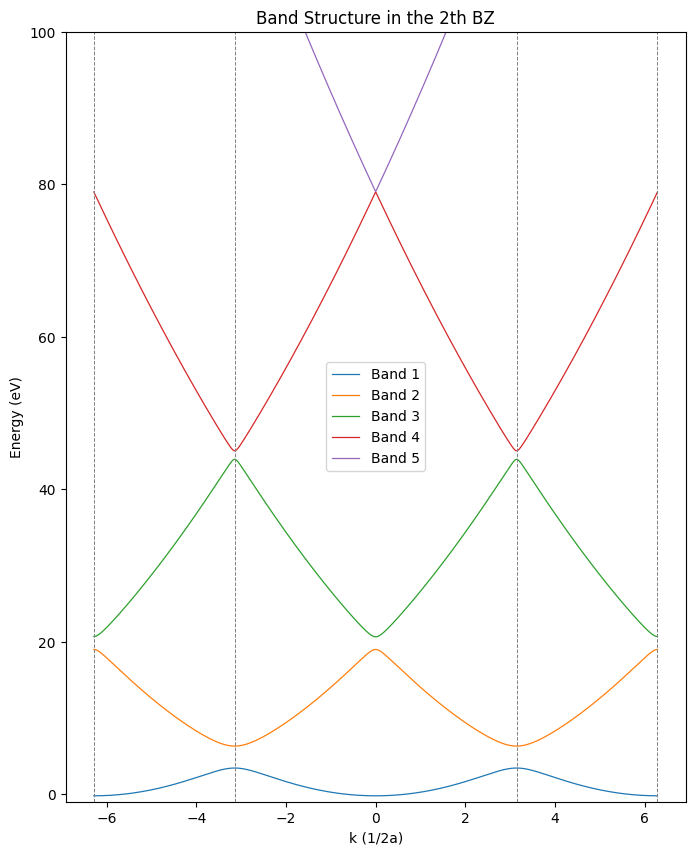

In [4]:
# Question 3: Converge the band-structure w.r.t the increasing number of Fourier basis used for expansion of the Bloch states.

# Use increasing number of plane waves and show convergence
VG = [{1 : A / 2},{1: A / 2, 2 : A / 4},{1: A / 2, 2: A / 4, 3: A / 6}]
for i in range(len(VG)):
    plot_bands(A, a, levels=5, bz=2, V_G_values=VG[i],N = 2000)
    plt.ylim(-1, 100)
    plt.show()

Mark the Fermi energy if each unitcell has one valence electrons.
Converge the Fermi energy w.r.t the increasing number unit cell considered in the supercell,
or in other words, finer k mesh.

Fermi Energy: 1.5971029704547108


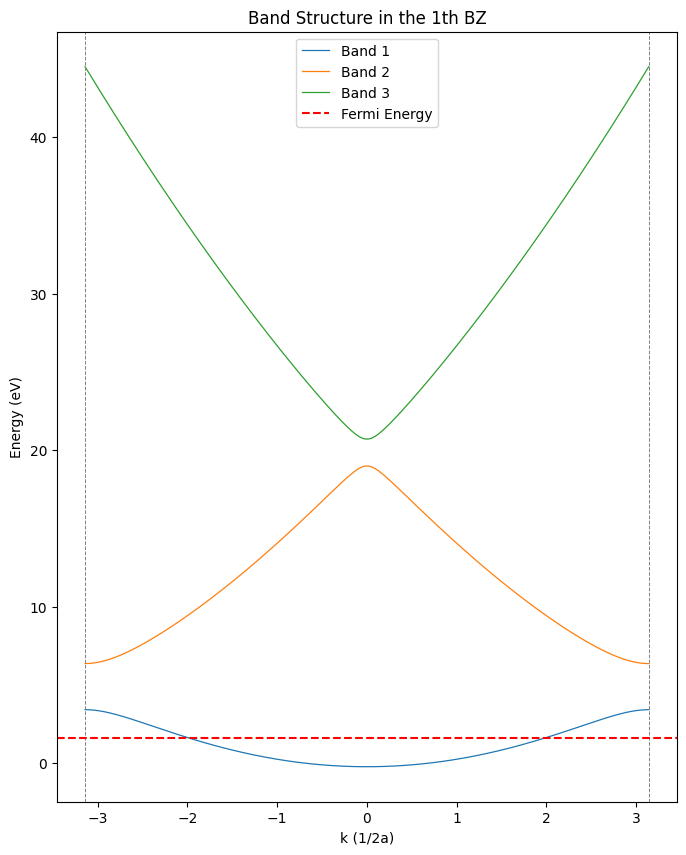

Converged Value of E_Fermi: 1.5971024735315011


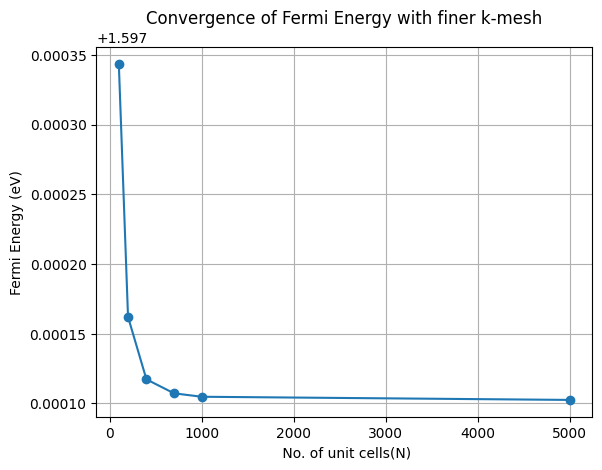

In [5]:
# Question 4: Plot the Fermi surface in the first BZ with one valence electron per unit cell.
#  With one valence electron per unit cell, the Fermi energy is between the 0 and 1st band.

plot_bands(A, a, levels=3, bz=1, V_G_values=VG_values,N = 2000)
# half of 1st band energy level
k_values, bands = band_structure(A, a, levels=5, bz=1, V_G_values=VG_values,N = 2000)
fermi_energy = (bands[0, :].max() + bands[0, :].min()) / 2 
print('Fermi Energy:', fermi_energy)
plt.axhline(fermi_energy, color='red', linestyle='--', label='Fermi Energy')
plt.legend()
plt.show()

# for finer k-mesh: convergence of fermi energy
fermi_energylist = []
N = [100,200,400,700,1000,5000]
for n in N:
    k_values, bands = band_structure(A, a, levels=5, bz=1, V_G_values=VG_values,N = n)
    fermi_energy = (bands[0, :].max() + bands[0, :].min()) / 2 
    fermi_energylist.append(fermi_energy)
print('Converged Value of E_Fermi:', fermi_energylist[-1])
plt.plot(N, fermi_energylist, marker='o')
plt.xlabel(' No. of unit cells(N)')
plt.ylabel('Fermi Energy (eV)')
plt.title('Convergence of Fermi Energy with finer k-mesh')
plt.grid()
plt.show()



Next add the potential 2*A *cos(0.5 pi/a). Plot bandstructure and density of states.

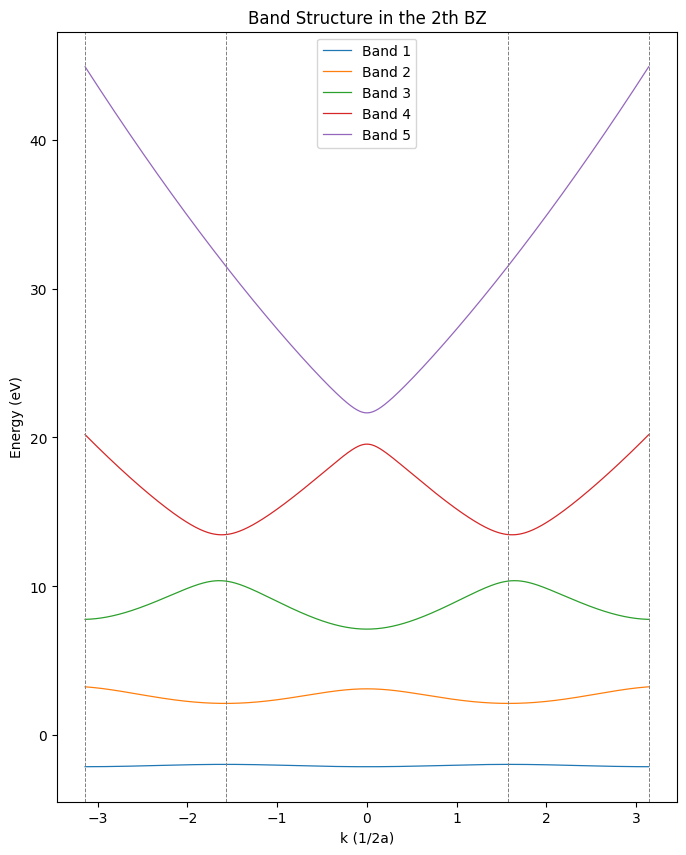

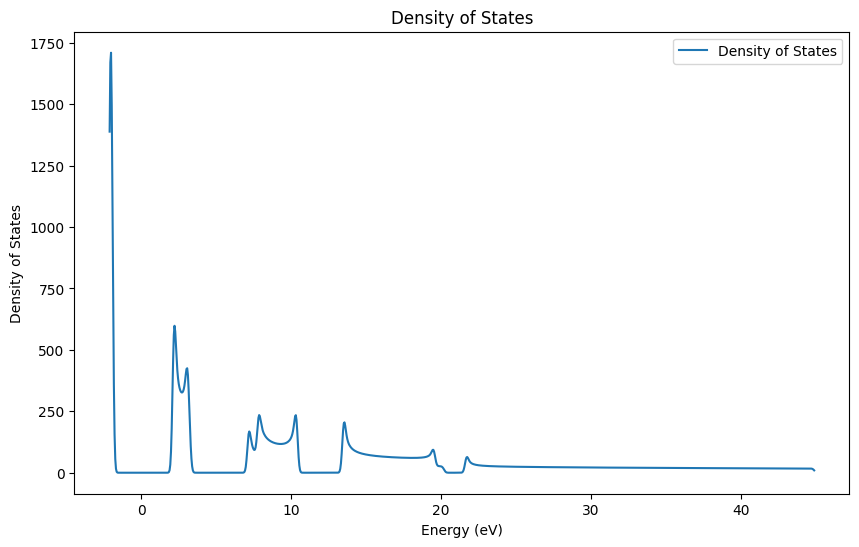

In [6]:
# Question 5 : Next add the potential 2*A *cos(0.5 pi/a). Plot bandstructure and density of states.
# Here lattice constant is 4a
V_modified = {1 : A, 2 : A/2, 3 : A / 4, 4 : A/6} 
# plot_bands(A, 4*a, levels=5, bz=1, V_G_values=V_modified,N = 2)
# plt.show()
plot_bands(A, 2*a, levels=5, bz=2, V_G_values=V_modified,N = 2000)
plt.show()
plot_dos(A, 2*a, levels=5, bz=2, V_G_values=V_modified,N = 2000)
plt.show()

Compute total energy per unit cell by simply adding the energy of the occupied states and
dividing it by . Plot the energy per unitcell as a function of A.
Note however that this is of course the most rudimentory and approximate approach to
compute total energy since we are not considering any interaction among the electrons.

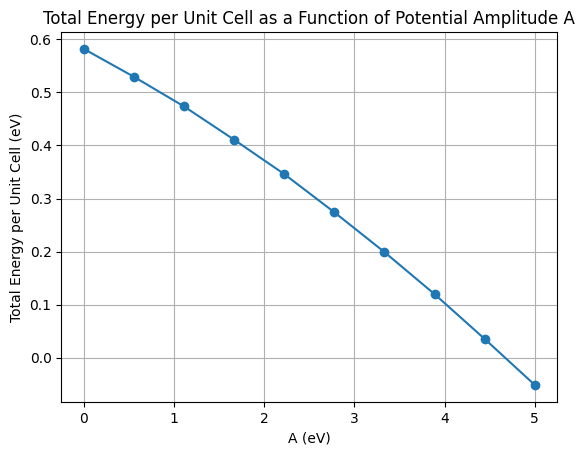

In [17]:
# Question 6:Compute total energy per unit cell by simply adding the energy of the occupied states and dividing it by N_{BVK}. 
# Plot the energy per unitcell as a function of A

tot_energy = []
A_values = np.linspace(0, 5, 10)
for A in A_values:
    V_G_values = {1: A / 2, 2: A / 4, 3: A / 6}
    k_values, bands = band_structure(A, a, levels=5, bz=1, V_G_values=V_G_values,N = 2000)
    fermi_energy = (bands[0, :].max() + bands[0, :].min()) / 2 
    occupied_states = bands[bands <= fermi_energy]
    total_energy_per_unit_cell = np.sum(occupied_states) / len(k_values)
    tot_energy.append(total_energy_per_unit_cell)

plt.plot(A_values, tot_energy, marker='o')
plt.xlabel('A (eV)')
plt.ylabel('Total Energy per Unit Cell (eV)')
plt.title('Total Energy per Unit Cell as a Function of Potential Amplitude A')
plt.grid()
plt.show()


One simple approach to improve on the computation of electronic structure within the single
particle picture is to solve the Poisson equation to obtain the potential due to the charge density of
the occupied states and add it to V(x) and iteratively converge the charge density.
You can easily do it by writing the Poisson equation in the Fourier basis.



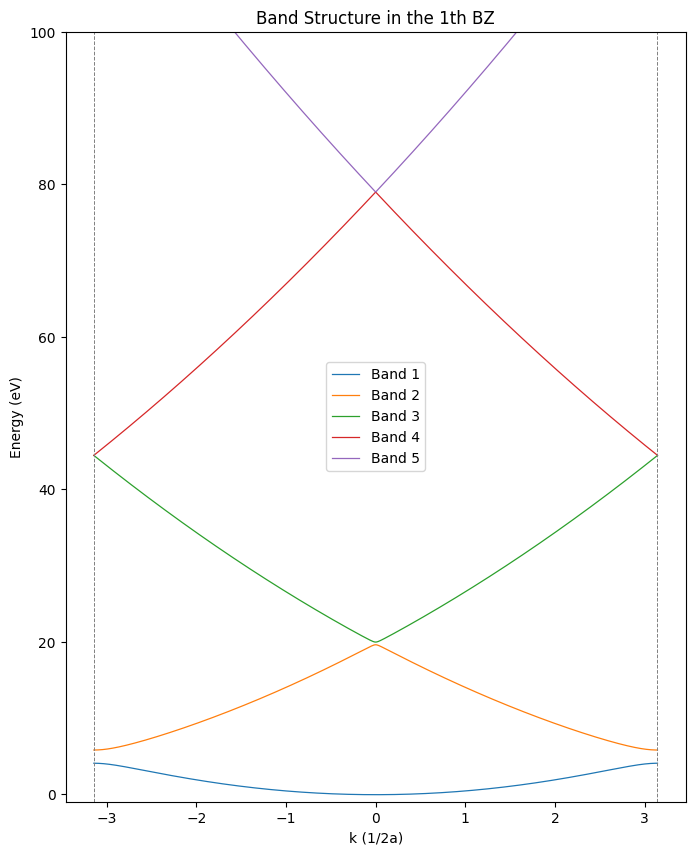

In [24]:

# Possion method for solving the Schrodinger equation in 1D periodic potential
Vg = {1: A / 2, 2: A / 4, 3: A / 6}
pass

def Hamiltonian(k, Vg, levels, a):
    H = np.zeros((levels, levels), dtype=float)
    G = 2 * np.pi / a
    g_values = np.array([ n * G for n in range(-levels//2 + 1, levels//2 + 1)])
    for i in range(levels):
        for j in range(levels):
            if i == j:
                H[i, j] =  0.5*((k - g_values[i])**2) # in atomic units
            else:
                H[i, j] = Vg.get(abs(i-j), 0)
    return H

def density_matrix(H, fermi_energy):
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    occupied_states = eigenvalues <= fermi_energy
    density_matrix = np.zeros_like(H)
    for i in range(len(eigenvalues)):
        if occupied_states[i]:
            density_matrix += np.outer(eigenvectors[:, i], eigenvectors[:, i])
    return density_matrix

def update_potential(density_matrix, a):
    G = 2 * np.pi / a
    Vg_updated = {}
    for n in range(-len(density_matrix)//2 + 1, len(density_matrix)//2 + 1):
        if n == 0:
            continue
        Vg_updated[n] = -4 * np.pi * density_matrix.sum() / (G * n)**2
    return Vg_updated

for iteration in range(100):
    k_values = np.linspace((-2*np.pi)/(2*a),(2*np.pi)/(2*a), 2000)
    H = Hamiltonian(k_values[1000], Vg, levels=5, a=a)
    fermi_energy = (np.linalg.eigvalsh(H).max() + np.linalg.eigvalsh(H).min()) / 2 
    density_mat = density_matrix(H, fermi_energy)
    Vg_converged = update_potential(density_mat, a)

plot_bands(A, a , levels=5, bz=1, V_G_values=Vg_converged,N = 2000)
plt.ylim(-1, 100)
plt.show()

